<a href="https://colab.research.google.com/github/cadmiofreitas/Aula_IA_UNIRP/blob/main/AG_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚚 Algoritmo Genético — Problema do Caminhão (Knapsack)

## O problema

Você tem um **caminhão** com espaço limitado e vários **produtos** disponíveis. Cada produto tem um volume (ocupa espaço) e um preço (vale dinheiro). **Quais produtos escolher para maximizar o faturamento sem estourar a capacidade?**

Testar todas as combinações é inviável — com 20 produtos já são mais de 1 milhão. Por isso usamos um **Algoritmo Genético**: simulamos a evolução de Darwin para que as melhores soluções sobrevivam e se reproduzam ao longo das gerações.

## A estratégia

Em vez de penalizar soluções inválidas, **reparamos** o cromossomo antes de avaliar:
1. Se o volume não estoura → mantém como está
2. Se estoura → remove iterativamente o produto de **pior** custo-benefício (R$/cm³) até caber

Vantagens: toda solução é válida por construção, sem precisar calibrar fator de penalização.

## 0) Instalação (apenas no Colab)

O Colab não vem com o `deap` instalado por padrão. Execute esta célula uma vez.

In [1]:
!pip install -q deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 12.4 MB/s eta 0:00:00


## 1) Importações

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

## 2) Parâmetros do problema

Mude os valores abaixo à vontade e re-execute as células seguintes.

In [3]:
SEED              = 42
N_PRODUTOS        = 20        # teste com 20, 100, 500, 1000
CAPACIDADE_CM3    = 1000

VOL_MIN, VOL_MAX     = 50, 300
PRECO_MIN, PRECO_MAX = 10, 500

TAM_POPULACAO     = 200
N_GERACOES        = 80
PROB_CROSSOVER    = 0.8
PROB_MUTACAO      = 0.2
PROB_FLIP_BIT     = 0.02
TAM_TORNEIO       = 3

random.seed(SEED)
np.random.seed(SEED)

## 3) Geração aleatória dos produtos

Sorteamos volume e preço de cada produto. Calculamos também o **custo-benefício** (R$/cm³) — quanto maior, melhor o produto.

In [4]:
volumes = [random.randint(VOL_MIN, VOL_MAX) for _ in range(N_PRODUTOS)]
precos  = [random.randint(PRECO_MIN, PRECO_MAX) for _ in range(N_PRODUTOS)]
custo_beneficio = [precos[i] / volumes[i] for i in range(N_PRODUTOS)]

volume_total_disponivel = sum(volumes)
preco_total_disponivel  = sum(precos)

print(f"Produtos disponíveis:         {N_PRODUTOS}")
print(f"Volume total se levasse TUDO: {volume_total_disponivel} cm³")
print(f"Capacidade do caminhão:       {CAPACIDADE_CM3} cm³")
print(f"Cabe ~{CAPACIDADE_CM3/volume_total_disponivel*100:.1f}% do volume")
print(f"Preço total se levasse TUDO:  R$ {preco_total_disponivel}")

pd.DataFrame({
    'ID': range(N_PRODUTOS),
    'Volume (cm³)': volumes,
    'Preço (R$)': precos,
    'R$/cm³': [round(c, 2) for c in custo_beneficio],
}).head(10)

Produtos disponíveis:         20
Volume total se levasse TUDO: 2872 cm³
Capacidade do caminhão:       1000 cm³
Cabe ~34.8% do volume
Preço total se levasse TUDO:  R$ 4981


,ID,Volume (cm³),Preço (R$),R$/cm³
0,0,213,121,0.57
1,1,78,129,1.65
2,2,56,268,4.79
3,3,239,318,1.33
4,4,120,23,0.19
5,5,112,297,2.65
6,6,107,111,1.04
7,7,85,376,4.42
8,8,238,342,1.44
9,9,76,369,4.86


## 4) Operador de Reparação

É o coração da solução robusta. Se um cromossomo (combinação de produtos) estourar a capacidade, removemos um a um os produtos de pior custo-benefício até caber.

In [5]:
def reparar(individuo):
    """Garante que o cromossomo respeite a capacidade do caminhão."""
    volume_atual = sum(volumes[i] for i, g in enumerate(individuo) if g == 1)

    if volume_atual <= CAPACIDADE_CM3:
        return individuo

    selecionados = [i for i, g in enumerate(individuo) if g == 1]
    selecionados.sort(key=lambda i: custo_beneficio[i])  # pior primeiro

    for idx in selecionados:
        if volume_atual <= CAPACIDADE_CM3:
            break
        individuo[idx] = 0
        volume_atual -= volumes[idx]

    return individuo

## 5) Configuração do DEAP

Define a estrutura do cromossomo (lista de 0s e 1s) e o tipo de fitness (queremos **maximizar** o preço).

In [6]:
if hasattr(creator, 'FitnessMax'):
    del creator.FitnessMax
if hasattr(creator, 'Individuo'):
    del creator.Individuo

creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individuo', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register('gene', random.randint, 0, 1)
toolbox.register('individuo', tools.initRepeat, creator.Individuo, toolbox.gene, n=N_PRODUTOS)
toolbox.register('populacao', tools.initRepeat, list, toolbox.individuo)

## 6) Função de Avaliação (Fitness)

Como o reparador garante que o volume nunca estoura, o fitness é apenas a soma dos preços.

In [7]:
def avaliar(individuo):
    return (sum(p for p, g in zip(precos, individuo) if g == 1),)

toolbox.register('evaluate', avaliar)

## 7) Operadores Genéticos com Reparação

- **Crossover (cxTwoPoint):** mistura pedaços de dois pais para gerar dois filhos
- **Mutação (mutFlipBit):** troca aleatoriamente alguns bits 0↔1
- **Seleção (selTournament):** escolhe 3 indivíduos ao acaso e o mais forte vence

In [8]:
def mate_com_reparacao(ind1, ind2):
    tools.cxTwoPoint(ind1, ind2)
    reparar(ind1)
    reparar(ind2)
    return ind1, ind2

def mutate_com_reparacao(ind):
    tools.mutFlipBit(ind, indpb=PROB_FLIP_BIT)
    reparar(ind)
    return (ind,)

toolbox.register('mate', mate_com_reparacao)
toolbox.register('mutate', mutate_com_reparacao)
toolbox.register('select', tools.selTournament, tournsize=TAM_TORNEIO)

## 8) Evolução

In [9]:
populacao = toolbox.populacao(n=TAM_POPULACAO)
for ind in populacao:
    reparar(ind)

hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('max',   np.max)
stats.register('media', np.mean)
stats.register('min',   np.min)

populacao_final, log = algorithms.eaSimple(
    populacao, toolbox,
    cxpb=PROB_CROSSOVER,
    mutpb=PROB_MUTACAO,
    ngen=N_GERACOES,
    stats=stats,
    halloffame=hof,
    verbose=True,
)

gen	nevals	max 	media  	min
0  	200   	2993	2149.57	902
1  	173   	3072	2414.97	1537
2  	166   	3316	2626.16	1084
3  	175   	3316	2844.28	1863
4  	169   	3316	3019.05	2205
5  	168   	3316	3129.89	2603
6  	158   	3316	3217.22	2789
7  	156   	3316	3257.07	2759
8  	178   	3316	3291.74	2861
9  	164   	3316	3294.85	2861
10 	154   	3316	3298.88	2848
11 	181   	3316	3292.57	2253
12 	168   	3316	3305.2 	2759
13 	166   	3316	3301.46	2593
14 	176   	3316	3310.72	2861
15 	171   	3316	3287.92	2861
16 	166   	3316	3306.06	2940
17 	161   	3316	3303.75	2796
18 	170   	3316	3299.72	2494
19 	155   	3316	3303.32	2861
20 	177   	3316	3300.11	2763
21 	152   	3316	3302.76	2672
22 	168   	3316	3302.68	2572
23 	166   	3316	3300.26	2789
24 	169   	3316	3302.96	2759
25 	169   	3316	3295.59	2762
26 	169   	3316	3307.94	2861
27 	169   	3316	3295.76	2732
28 	159   	3316	3307.41	2892
29 	167   	3316	3305.18	2763
30 	166   	3316	3307.7 	2914
31 	179   	3316	3302.7 	2947
32 	164   	3316	3299.25	2892
33 	159   	3316	

## 9) Relatório da melhor solução

In [10]:
melhor = hof[0]
embarcados = [i for i, g in enumerate(melhor) if g == 1]
volume_usado = sum(volumes[i] for i in embarcados)
preco_total  = sum(precos[i] for i in embarcados)

print(f"Produtos embarcados: {len(embarcados)} de {N_PRODUTOS}")
print(f"Volume usado:        {volume_usado} / {CAPACIDADE_CM3} cm³ ({volume_usado/CAPACIDADE_CM3*100:.1f}%)")
print(f"Faturamento total:   R$ {preco_total}")
print(f"Eficiência:          {preco_total/preco_total_disponivel*100:.1f}% do faturamento máximo possível")

df_resultado = pd.DataFrame({
    'ID': embarcados,
    'Volume (cm³)': [volumes[i] for i in embarcados],
    'Preço (R$)': [precos[i] for i in embarcados],
    'R$/cm³': [round(custo_beneficio[i], 2) for i in embarcados],
}).sort_values('R$/cm³', ascending=False).reset_index(drop=True)

df_resultado

Produtos embarcados: 10 de 20
Volume usado:        991 / 1000 cm³ (99.1%)
Faturamento total:   R$ 3316
Eficiência:          66.6% do faturamento máximo possível


,ID,Volume (cm³),Preço (R$),R$/cm³
0,17,58,455,7.84
1,19,73,398,5.45
2,9,76,369,4.86
3,2,56,268,4.79
4,7,85,376,4.42
5,14,72,311,4.32
6,16,158,424,2.68
7,5,112,297,2.65
8,1,78,129,1.65
9,10,223,289,1.30


## 10) Gráfico da evolução

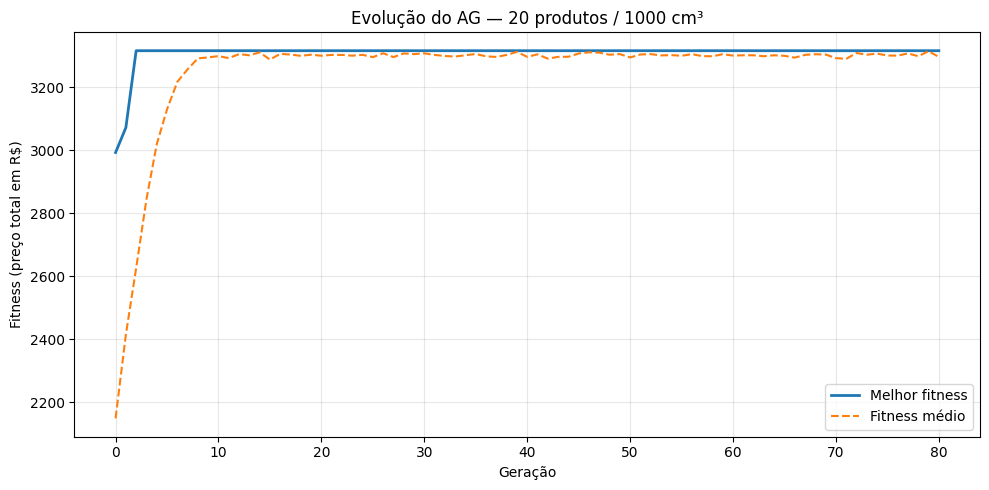

In [11]:
geracoes = log.select('gen')
maximos  = log.select('max')
medias   = log.select('media')

plt.figure(figsize=(10, 5))
plt.plot(geracoes, maximos, label='Melhor fitness', linewidth=2)
plt.plot(geracoes, medias,  label='Fitness médio', linestyle='--')
plt.xlabel('Geração')
plt.ylabel('Fitness (preço total em R$)')
plt.title(f'Evolução do AG — {N_PRODUTOS} produtos / {CAPACIDADE_CM3} cm³')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# 🎮 Playground Interativo (sliders!)

Esta seção é independente das anteriores. Usa **`ipywidgets`** para criar sliders nativos do notebook. Mexa nos controles e clique em **Rodar Algoritmo** — o gráfico, a tabela e as métricas atualizam automaticamente.

Funciona no **Jupyter, VS Code e Google Colab**.

In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Sliders ---
w_n_produtos = widgets.IntSlider(value=20,   min=5, max=500, step=5,   description='Nº produtos:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_capacidade = widgets.IntSlider(value=1000, min=200, max=5000, step=100, description='Capacidade (cm³):', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_vol        = widgets.IntRangeSlider(value=[50, 300], min=10, max=500, step=10, description='Volume (cm³):', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_preco      = widgets.IntRangeSlider(value=[10, 500], min=1, max=1000, step=10, description='Preço (R$):', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_pop        = widgets.IntSlider(value=200,  min=20, max=500, step=20, description='Tam. população:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_geracoes   = widgets.IntSlider(value=80,   min=10, max=300, step=10, description='Nº gerações:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_cx         = widgets.FloatSlider(value=0.8, min=0.0, max=1.0, step=0.05, description='Prob. crossover:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_mut        = widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description='Prob. mutação:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_flip       = widgets.FloatSlider(value=0.02, min=0.0, max=0.2, step=0.01, description='Prob. flip bit:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_torneio    = widgets.IntSlider(value=3,    min=2, max=10, step=1, description='Tam. torneio:', style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))
w_seed       = widgets.IntText(value=42, description='Seed:', style={'description_width': '160px'}, layout=widgets.Layout(width='300px'))

btn = widgets.Button(description='▶️ Rodar Algoritmo', button_style='success', layout=widgets.Layout(width='250px'))
out = widgets.Output()


def executar_ag(n_prod, cap, vmin, vmax, pmin, pmax, tpop, ngen, pcx, pmut, pflip, torn, seed):
    random.seed(seed)
    np.random.seed(seed)

    vols = [random.randint(vmin, vmax) for _ in range(n_prod)]
    prs  = [random.randint(pmin, pmax) for _ in range(n_prod)]
    cb   = [prs[i] / vols[i] for i in range(n_prod)]

    def rep(ind):
        v = sum(vols[i] for i, g in enumerate(ind) if g == 1)
        if v <= cap:
            return ind
        sel = sorted([i for i, g in enumerate(ind) if g == 1], key=lambda i: cb[i])
        for idx in sel:
            if v <= cap:
                break
            ind[idx] = 0
            v -= vols[idx]
        return ind

    if hasattr(creator, 'FitnessMax'):
        del creator.FitnessMax
    if hasattr(creator, 'Individuo'):
        del creator.Individuo
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individuo', list, fitness=creator.FitnessMax)

    tb = base.Toolbox()
    tb.register('gene', random.randint, 0, 1)
    tb.register('individuo', tools.initRepeat, creator.Individuo, tb.gene, n=n_prod)
    tb.register('populacao', tools.initRepeat, list, tb.individuo)
    tb.register('evaluate', lambda ind: (sum(p for p, g in zip(prs, ind) if g == 1),))

    def mate(i1, i2):
        tools.cxTwoPoint(i1, i2); rep(i1); rep(i2)
        return i1, i2

    def mut(i):
        tools.mutFlipBit(i, indpb=pflip); rep(i)
        return (i,)

    tb.register('mate', mate)
    tb.register('mutate', mut)
    tb.register('select', tools.selTournament, tournsize=torn)

    pop = tb.populacao(n=tpop)
    for ind in pop:
        rep(ind)

    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('max', np.max)
    stats.register('media', np.mean)

    _, log = algorithms.eaSimple(pop, tb, cxpb=pcx, mutpb=pmut, ngen=ngen,
                                  stats=stats, halloffame=hof, verbose=False)
    return vols, prs, cb, hof[0], log


def on_click(_):
    with out:
        clear_output(wait=True)
        print('Evoluindo a população...')
        vols, prs, cb, melhor, log = executar_ag(
            w_n_produtos.value, w_capacidade.value,
            w_vol.value[0], w_vol.value[1],
            w_preco.value[0], w_preco.value[1],
            w_pop.value, w_geracoes.value,
            w_cx.value, w_mut.value, w_flip.value,
            w_torneio.value, w_seed.value,
        )
        clear_output(wait=True)

        emb = [i for i, g in enumerate(melhor) if g == 1]
        vu  = sum(vols[i] for i in emb)
        pt  = sum(prs[i]  for i in emb)
        pdisp = sum(prs)

        print('=' * 60)
        print(f'💰 Faturamento:        R$ {pt}  (de R$ {pdisp} possíveis)')
        print(f'📦 Volume usado:       {vu} / {w_capacidade.value} cm³ ({vu/w_capacidade.value*100:.1f}%)')
        print(f'✅ Produtos embarcados: {len(emb)} de {w_n_produtos.value}')
        print(f'📊 Eficiência:         {pt/pdisp*100:.1f}% do máximo possível')
        print('=' * 60)

        df = pd.DataFrame({
            'ID': emb,
            'Volume (cm³)': [vols[i] for i in emb],
            'Preço (R$)':   [prs[i]  for i in emb],
            'R$/cm³':       [round(cb[i], 2) for i in emb],
        }).sort_values('R$/cm³', ascending=False).reset_index(drop=True)
        display(df)

        ger = log.select('gen')
        mx  = log.select('max')
        md  = log.select('media')
        plt.figure(figsize=(10, 4))
        plt.plot(ger, mx, label='Melhor fitness', linewidth=2)
        plt.plot(ger, md, label='Fitness médio', linestyle='--')
        plt.xlabel('Geração')
        plt.ylabel('Fitness (R$)')
        plt.title(f'Evolução — {w_n_produtos.value} produtos / {w_capacidade.value} cm³')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


btn.on_click(on_click)

controles = widgets.VBox([
    widgets.HTML('<b>Problema:</b>'),
    w_n_produtos, w_capacidade, w_vol, w_preco,
    widgets.HTML('<b>Algoritmo:</b>'),
    w_pop, w_geracoes, w_cx, w_mut, w_flip, w_torneio, w_seed,
    btn,
])

display(controles, out)

Output()